# Model evaluation — Congestion fee 

**Task :** Compare how well three model types **rank** trips by likelihood of the **CBD congestion fee** (`has_congestion_fee`), using the **same test data** for a fair comparison.

**Models compared**
- **Logistic regression** (baseline)
- **Random Forest** 
- **XGBoost classifier**

**Outputs**
- **ROC curves** 
- **AUC** 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("Note: xgboost not installed — ROC will show logistic + RF only.")

try:
    plt.style.use("seaborn-v0_8")
except Exception:
    plt.style.use("default")

RANDOM_STATE = 42
SAMPLE_SIZE = 500_000

In [2]:
# Load + sample + features (same rules as Abhishek_RF / Moses_RF)
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
data = data.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

y_congestion = data["has_congestion_fee"]
y_duration = data["trip_duration_min"]

drop_cols = [
    "trip_duration_min",
    "has_congestion_fee",
    "tpep_pickup_datetime",
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name",
]
existing_drops = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drops)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    if X[col].dtype.name == "category":
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = le.fit_transform(X[col])

X_train, X_test, _, _, y_train, y_test = train_test_split(
    X, y_duration, y_congestion,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_congestion,
)

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

print(f"Train {X_train.shape[0]:,} | Test {X_test.shape[0]:,} | Features {X_train.shape[1]}")
print(f"Test positive rate (fee): {y_test.mean():.3f}")

Train 400,000 | Test 100,000 | Features 21
Test positive rate (fee): 0.744


In [3]:
# Fit models (same train; probabilities on same test)
models = {}

lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced")
lr.fit(X_train_lr, y_train)
models["Logistic regression"] = (lr, X_test_lr)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
models["Random Forest"] = (rf, X_test)

if HAS_XGB:
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss",
    )
    xgb.fit(X_train, y_train)
    models["XGBoost"] = (xgb, X_test)

print("Fitted:", ", ".join(models.keys()))

Fitted: Logistic regression, Random Forest, XGBoost


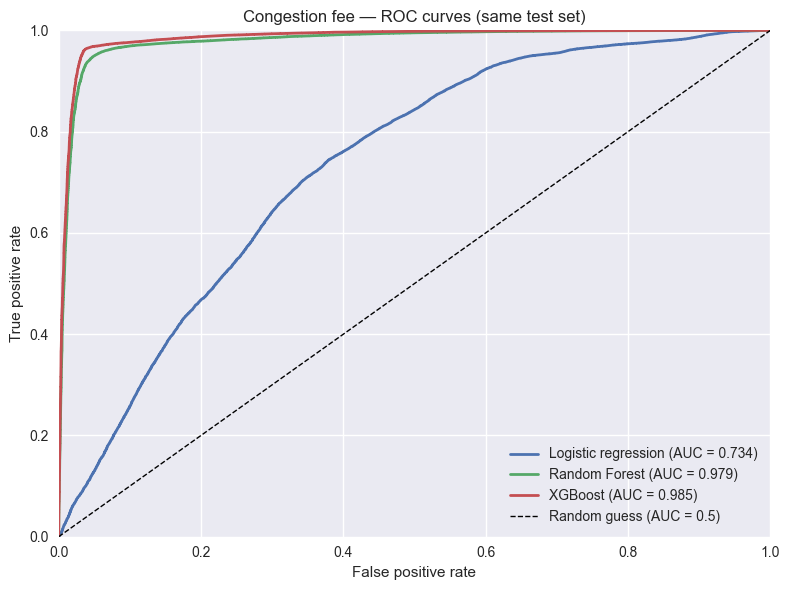

              Model  Test ROC-AUC
            XGBoost        0.9850
      Random Forest        0.9794
Logistic regression        0.7336


In [4]:
# ROC curves + AUC table
fig, ax = plt.subplots(figsize=(8, 6))

rows = []
for name, (clf, X_te) in models.items():
    proba = clf.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")
    rows.append({"Model": name, "Test ROC-AUC": round(float(auc), 4)})

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random guess (AUC = 0.5)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Congestion fee — ROC curves (same test set)")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

auc_table = pd.DataFrame(rows).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)
print(auc_table.to_string(index=False))

## Takeaways

- **Best ranking model (this run):** **XGBoost** has the highest test **ROC-AUC (0.985)**, slightly ahead of **Random Forest (0.979)**. Both sit far above **random guessing (0.5)** and show strong ability to order trips by congestion-fee risk on the held-out 100k test rows.

- **Baseline vs ensembles:** **Logistic regression** reaches **AUC ≈ 0.734**—much lower than the tree models. That gap supports using **non-linear** models for this task: pickup/dropoff zones, time, and interactions are not well captured by a single linear score, which matches our EDA and feature design.

- **ROC shape (read with the plot):** All three curves bow well above the diagonal; the **ensemble curves** hug the top-left corner more tightly than logistic, meaning we can achieve a **better tradeoff** between catching fee trips and limiting false alarms when we choose an operating threshold.


The CBD congestion fee is partly determined by where and when a trip happens. We compared logistic regression to Random Forest and XGBoost on the same test trips. The tree models achieved much higher ROC-AUC than logistic regression, meaning they better separate trips that incur the fee from those that do not when we rank trips by predicted fee risk. That supports using ensemble methods for congestion-fee prediction in this study and aligns with the project’s focus on spatial and temporal patterns in NYC taxi data.